<a href="https://colab.research.google.com/github/Gaddy01/Time-Series-Forcasting/blob/main/02_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2. Exploratory Data Analysis

This notebook explores the geographical and temporal characteristics of mobile
network Internet traffic in the Milan telecommunications dataset.

The analysis focuses on:

1. The distribution of total Internet traffic across geographical areas.
2. Identification of the three geographical areas with the highest total Internet traffic.
3. Comparison of Internet traffic patterns across five geographical areas during
   the first two weeks of the observation period.
4. Two additional time-series analyses of the highest-traffic area to identify
   characteristics relevant to one-step-ahead forecasting.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from google.colab import drive

In [ ]:
# CONNECT TO GOOGLE DRIVE

drive.mount("/content/drive")

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/ML Techniques I/Formative 1"
)

MASTER_PARQUET = (
    DRIVE_PROJECT
    / "data"
    / "telecom_milan_master.parquet"
)

print("Master dataset:")
print(MASTER_PARQUET)

print("\nFile exists:", MASTER_PARQUET.exists())

if MASTER_PARQUET.exists():
    print(
        f"File size: "
        f"{MASTER_PARQUET.stat().st_size / (1024**3):.2f} GB"
    )

Mounted at /content/drive
Master dataset:
/content/drive/MyDrive/ML Techniques I/Formative 1/data/telecom_milan_master.parquet

File exists: True
File size: 1.74 GB


Let's now Inspect the structure of the Parquet dataset

In [ ]:
parquet_file = pq.ParquetFile(MASTER_PARQUET)

print("=" * 70)
print("MASTER DATASET")
print("=" * 70)

print(f"Rows:       {parquet_file.metadata.num_rows:,}")
print(f"Columns:    {parquet_file.metadata.num_columns:,}")
print(f"Row groups: {parquet_file.num_row_groups:,}")

print("\nSchema:")
print(parquet_file.schema_arrow)

MASTER DATASET
Rows:       89,245,318
Columns:    7
Row groups: 124

Schema:
square_id: int16
timestamp: int64
sms_in: float
sms_out: float
call_in: float
call_out: float
internet: float
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 900


One important issue is that the dataset has 117,845 missing Internet observations.

Here, we're going to exclude missing values from the sum rather than treating them as zero. This is because a missing activity value does not necessarily mean that the geographical area had zero Internet activity.

Let's first Calculate the total Internet traffic per square

In [ ]:
print("=" * 70)
print("CALCULATING TOTAL INTERNET TRAFFIC BY SQUARE")
print("=" * 70)

# Read only the two columns needed for this analysis
internet_data = pd.read_parquet(
    MASTER_PARQUET,
    columns=["square_id", "internet"]
)

print(f"Rows loaded: {len(internet_data):,}")

# Calculate total Internet activity for each square.
# Missing Internet observations are excluded from the sum.
traffic_by_square = (
    internet_data
    .groupby("square_id")["internet"]
    .sum()
    .sort_values(ascending=False)
    .rename("total_internet")
    .reset_index()
)

print(f"Unique squares: {traffic_by_square['square_id'].nunique():,}")

print("\nTop 10 geographical areas by total Internet traffic:")
print(
    traffic_by_square.head(10).to_string(index=False)
)

CALCULATING TOTAL INTERNET TRAFFIC BY SQUARE
Rows loaded: 89,245,318
Unique squares: 10,000

Top 10 geographical areas by total Internet traffic:
 square_id  total_internet
      5161      12740060.0
      5059      11170854.0
      5259      10485780.0
      5061       9584334.0
      5258       8707440.0
      5159       8703873.0
      6064       8675343.0
      4855       8491044.0
      4856       8230212.0
      5262       8163357.0


Now let's Check the missing Internet observations

In [ ]:
missing_by_square = (
    internet_data
    .assign(internet_missing=internet_data["internet"].isna())
    .groupby("square_id")["internet_missing"]
    .agg(
        missing_count="sum",
        observation_count="count"
    )
    .reset_index()
)

missing_by_square["missing_percentage"] = (
    missing_by_square["missing_count"]
    / (
        missing_by_square["missing_count"]
        + missing_by_square["observation_count"]
    )
    * 100
)

print("=" * 70)
print("INTERNET MISSINGNESS")
print("=" * 70)

print(f"Total missing Internet observations: {internet_data['internet'].isna().sum():,}")
print(f"Overall missing percentage: {internet_data['internet'].isna().mean() * 100:.4f}%")
print("\nSquares with the highest missing percentages:")
print(
    missing_by_square
    .sort_values("missing_percentage", ascending=False)
    .head(10)
    .to_string(index=False)
)

INTERNET MISSINGNESS
Total missing Internet observations: 117,845
Overall missing percentage: 0.1320%

Squares with the highest missing percentages:
 square_id  missing_count  observation_count  missing_percentage
      5239           2141               2883           42.615446
      4574           4032               8176           33.027523
      4472           4197               8720           32.492065
      4572           4153               8815           32.024985
      4570           3989               8563           31.779796
      4571           4037               8681           31.742412
      4671           3982               8620           31.598159
      4471           3754               8277           31.202726
      4672           3848               8563           31.004754
      5340           3371               7755           30.298400


Now, let's combine the results by creating one clean table containing the traffic ranking and missingness.

In [ ]:
traffic_summary = traffic_by_square.merge(
    missing_by_square,
    on="square_id",
    how="left"
)

traffic_summary["traffic_rank"] = (
    traffic_summary["total_internet"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

print("=" * 70)
print("TOP 10 GEOGRAPHICAL AREAS")
print("=" * 70)

print(
    traffic_summary
    .head(10)
    .to_string(index=False)
)

TOP 10 GEOGRAPHICAL AREAS
 square_id  total_internet  missing_count  observation_count  missing_percentage  traffic_rank
      5161      12740060.0              0               8928                 0.0             1
      5059      11170854.0              0               8928                 0.0             2
      5259      10485780.0              0               8928                 0.0             3
      5061       9584334.0              0               8928                 0.0             4
      5258       8707440.0              0               8928                 0.0             5
      5159       8703873.0              0               8928                 0.0             6
      6064       8675343.0              0               8928                 0.0             7
      4855       8491044.0              0               8928                 0.0             8
      4856       8230212.0              0               8928                 0.0             9
      5262       8163357

Let's now Save the complete geographical traffic summary

In [ ]:
TABLES_DIR = DRIVE_PROJECT / "results" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

traffic_summary_path = (
    TABLES_DIR / "internet_traffic_by_square.csv"
)

traffic_summary.to_csv(
    traffic_summary_path,
    index=False
)

print(f"Saved to: {traffic_summary_path}")

Saved to: /content/drive/MyDrive/ML Techniques I/Formative 1/results/tables/internet_traffic_by_square.csv


Let's now inspect the Distribution of Total Internet Traffic

In [ ]:
traffic_values = traffic_summary["total_internet"]

print("=" * 70)
print("TOTAL INTERNET TRAFFIC DISTRIBUTION")
print("=" * 70)

print(traffic_values.describe())

print("\nAdditional statistics:")
print(f"Median: {traffic_values.median():,.2f}")
print(f"Skewness: {traffic_values.skew():.3f}")

print(f"\nMinimum: {traffic_values.min():,.2f}")
print(f"Maximum: {traffic_values.max():,.2f}")

TOTAL INTERNET TRAFFIC DISTRIBUTION
count    1.000000e+04
mean     5.552894e+05
std      8.925967e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
max      1.274006e+07
Name: total_internet, dtype: float64

Additional statistics:
Median: 277,871.09
Skewness: 4.265

Minimum: 213.63
Maximum: 12,740,060.00


The distribution of total Internet traffic across the 10,000 geographical areas is strongly **right-skewed**. The mean total traffic is 555,289.40, while the median is substantially lower at 277,871.09. The positive skewness of **4.265** indicates that most geographical areas have relatively low to moderate levels of Internet activity, while a smaller number of areas have considerably higher traffic volumes. This is also reflected by the large range, from 213.63 to 12,740,060.00, and the standard deviation of 892,596.70.

Let's now plot the Distribution of Total Internet Traffic Across Squares

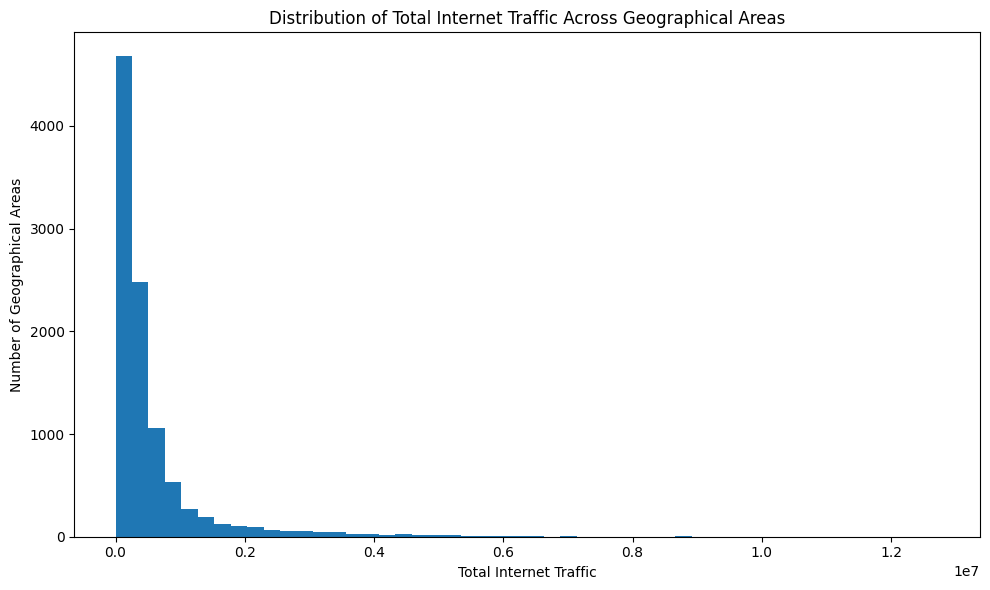

Figure saved to: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/internet_traffic_distribution.png


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(traffic_values,bins=50)

plt.xlabel("Total Internet Traffic")
plt.ylabel("Number of Geographical Areas")
plt.title("Distribution of Total Internet Traffic Across Geographical Areas")

plt.tight_layout()

FIGURES_DIR = DRIVE_PROJECT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

distribution_path = (FIGURES_DIR / "internet_traffic_distribution.png")

plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {distribution_path}")

We notice that this **linear-scale histogram** is useful for showing the actual magnitude of traffic, but because a few areas have extremely large values, the majority of geographical areas are compressed toward the left side.

That's why we're going to create the same Traffic Distribution figure, but in a Log-Scale View

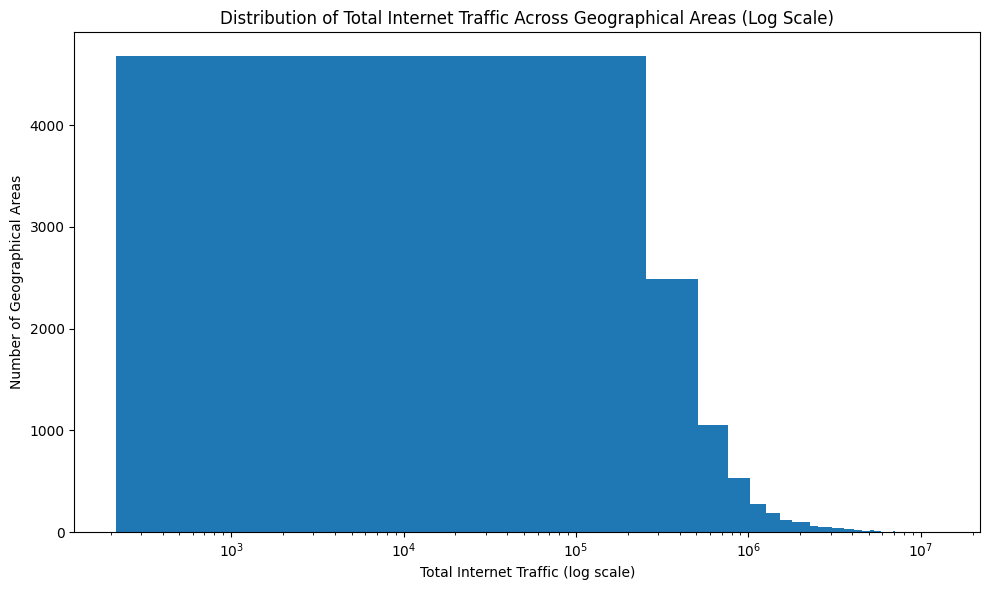

Figure saved to: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/internet_traffic_distribution_log.png


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(traffic_values,bins=50)

plt.xscale("log")

plt.xlabel("Total Internet Traffic (log scale)")
plt.ylabel("Number of Geographical Areas")
plt.title("Distribution of Total Internet Traffic Across Geographical Areas (Log Scale)")

plt.tight_layout()

log_distribution_path = (FIGURES_DIR / "internet_traffic_distribution_log.png")

plt.savefig(
    log_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {log_distribution_path}")

Because the distribution spans several orders of magnitude, we notice that **the log-scale histogram** provides a clearer view of the concentration and spread of the majority of geographical areas. It confirm the rigt-skewness we noted from the statistical description.

We will now extract the three highest-traffic geographical areas, and plot the first two weeks for those three areas + the areas 4159 and 4556.

In [ ]:
# Top 3 Geographical Areas by Total Internet Traffic

top_3_areas = (
    traffic_summary
    .sort_values("total_internet", ascending=False)
    .head(3)
    .copy()
)

top_3_areas["total_internet"] = (
    top_3_areas["total_internet"]
    .round(2)
)

print("=" * 70)
print("TOP 3 GEOGRAPHICAL AREAS BY TOTAL INTERNET TRAFFIC")
print("=" * 70)

display(
    top_3_areas[
        [
            "traffic_rank",
            "square_id",
            "total_internet",
            "missing_count",
            "missing_percentage"
        ]
    ]
)

TOP 3 GEOGRAPHICAL AREAS BY TOTAL INTERNET TRAFFIC


,traffic_rank,square_id,total_internet,missing_count,missing_percentage
0,1,5161,12740060.0,0,0.0
1,2,5059,11170854.0,0,0.0
2,3,5259,10485780.0,0,0.0


In [ ]:
# Define the 5 areas Selected for Temporal Analysis

top_3_ids = top_3_areas["square_id"].tolist()

selected_square_ids = top_3_ids + [4159, 4556]

print("Selected geographical areas:")
for rank, square_id in enumerate(selected_square_ids, start=1):
    print(f"{rank}. Square {square_id}")

Selected geographical areas:
1. Square 5161
2. Square 5059
3. Square 5259
4. Square 4159
5. Square 4556


In [ ]:
# First Two Weeks of Observation

time_data = pd.read_parquet(MASTER_PARQUET, columns=["timestamp"])
time_data["datetime"] = pd.to_datetime(time_data["timestamp"], unit="ms")

dataset_start = time_data["datetime"].min()
first_two_weeks_end = (dataset_start + pd.Timedelta(days=14))

print(f"Dataset start:       {dataset_start}")
print(f"First two weeks end: {first_two_weeks_end}")

del time_data

Dataset start:       2013-10-31 23:00:00
First two weeks end: 2013-11-14 23:00:00


In [ ]:
# Extract Internet Traffic for Selected Areas (5 areas)

selected_data = pd.read_parquet(MASTER_PARQUET, columns=["square_id", "timestamp", "internet"])
selected_data["datetime"] = pd.to_datetime(selected_data["timestamp"], unit="ms")

first_two_weeks = selected_data[
    (selected_data["datetime"] >= dataset_start) &
    (selected_data["datetime"] < first_two_weeks_end) &
    (selected_data["square_id"].isin(selected_square_ids))
].copy()

first_two_weeks = first_two_weeks.sort_values(
    ["square_id", "datetime"]
)

print("=" * 70)
print("FIRST TWO WEEKS — SELECTED AREAS")
print("=" * 70)
print(f"Rows: {len(first_two_weeks):,}")
print(f"Squares: {first_two_weeks['square_id'].nunique()}")
print(f"Time range: {first_two_weeks['datetime'].min()} to {first_two_weeks['datetime'].max()}")

FIRST TWO WEEKS — SELECTED AREAS
Rows: 10,080
Squares: 5
Time range: 2013-10-31 23:00:00 to 2013-11-14 22:50:00


Before plotting, let'c ckeck whether 4159 and 4556 have missing observations during the specific two-week period.

In [ ]:
missing_check = (
    first_two_weeks
    .groupby("square_id")["internet"]
    .agg(
        observations="size",
        missing_count=lambda x: x.isna().sum()
    )
    .reset_index()
)

missing_check["missing_percentage"] = (
    missing_check["missing_count"]
    / missing_check["observations"]
    * 100
)

display(missing_check)

,square_id,observations,missing_count,missing_percentage
0,4159,2016,0,0.0
1,4556,2016,0,0.0
2,5059,2016,0,0.0
3,5161,2016,0,0.0
4,5259,2016,0,0.0


Excellet! As there is no missing values, let's now plot the 5 selected areas for the first two weeks.

So, for the first two weeks, all five selected areas have exactly 2,016 observations and zero missing values. This is particularly useful because it means we can compare their temporal behavior without having to introduce an imputation method

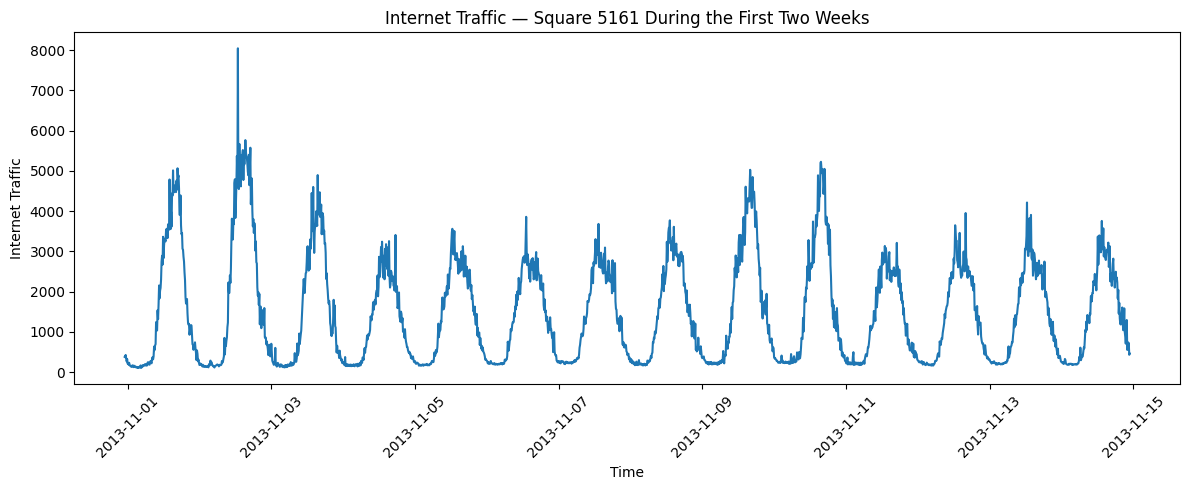

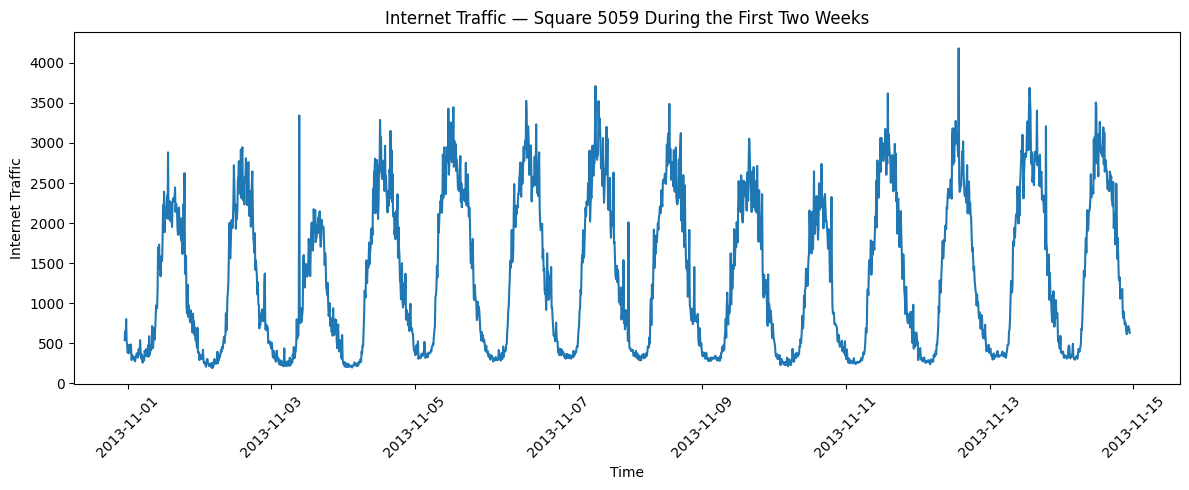

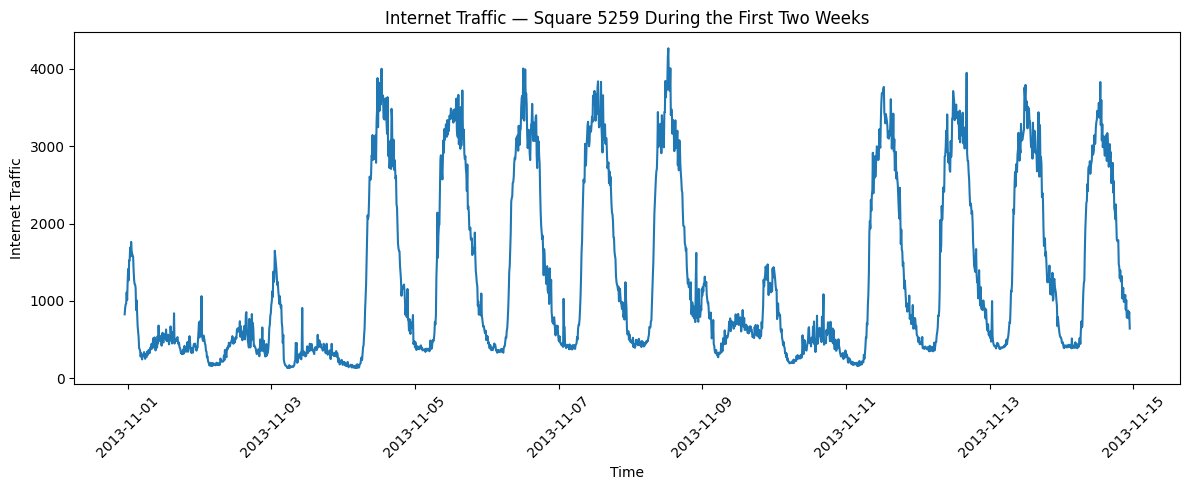

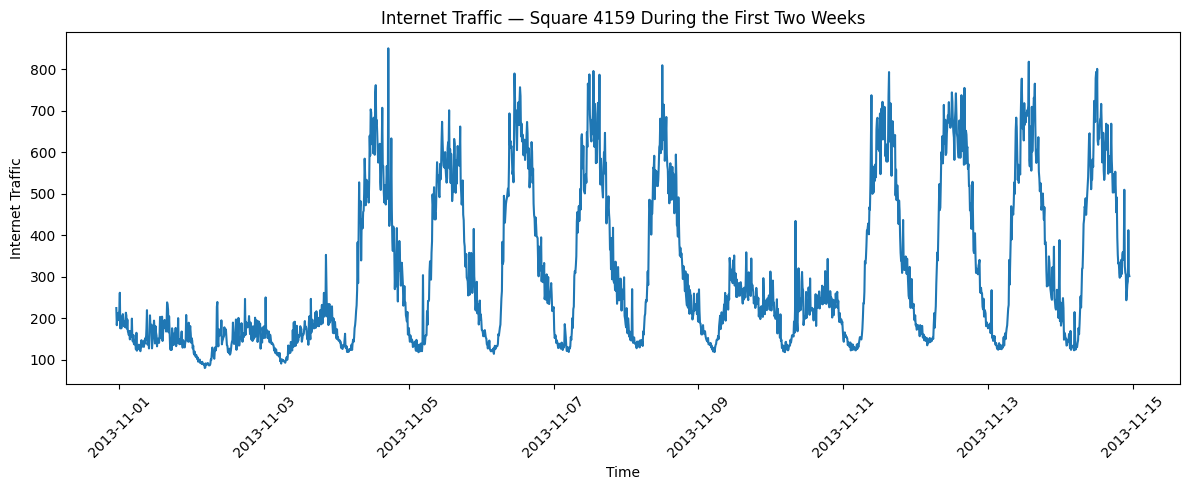

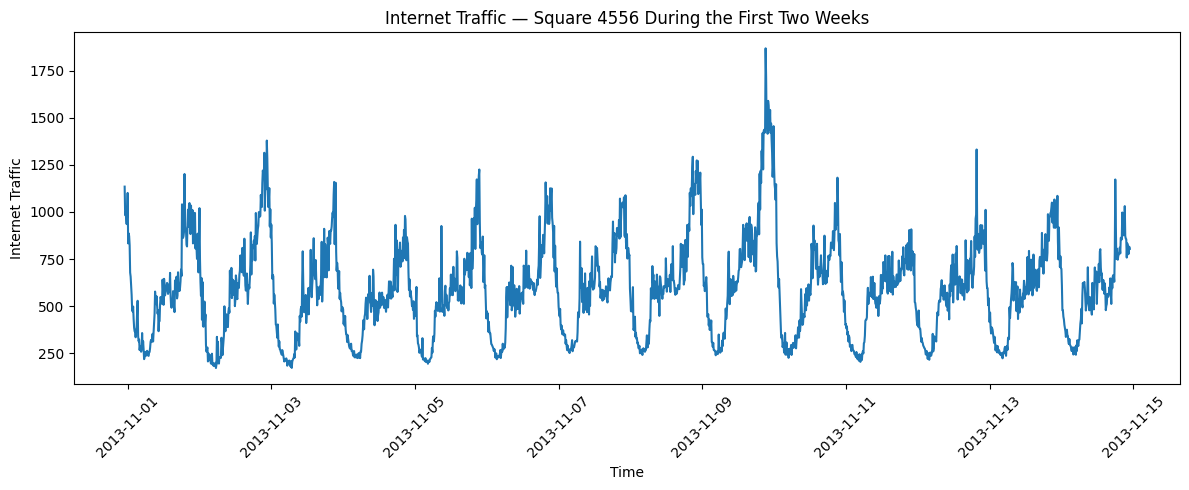

In [ ]:
# Internet Traffic During the First Two Weeks

for square_id in selected_square_ids:

    square_data = first_two_weeks[
        first_two_weeks["square_id"] == square_id
    ]

    plt.figure(figsize=(12, 5))
    plt.plot(square_data["datetime"], square_data["internet"])

    plt.xlabel("Time")
    plt.ylabel("Internet Traffic")
    plt.title(f"Internet Traffic — Square {square_id} During the First Two Weeks")

    plt.xticks(rotation=45)
    plt.tight_layout()

    figure_path = (
        FIGURES_DIR
        / f"internet_traffic_square_{square_id}_first_two_weeks.png"
    )

    plt.savefig(figure_path, dpi=300, bbox_inches="tight")

    plt.show()

The raw plots let us compare absolute traffic levels, but because the five areas can have very different scales, they don't make it easy to compare their temporal patterns.

for that, we're going to normalize each square by its mean, and combine all of the 5 plots in one visual representation.

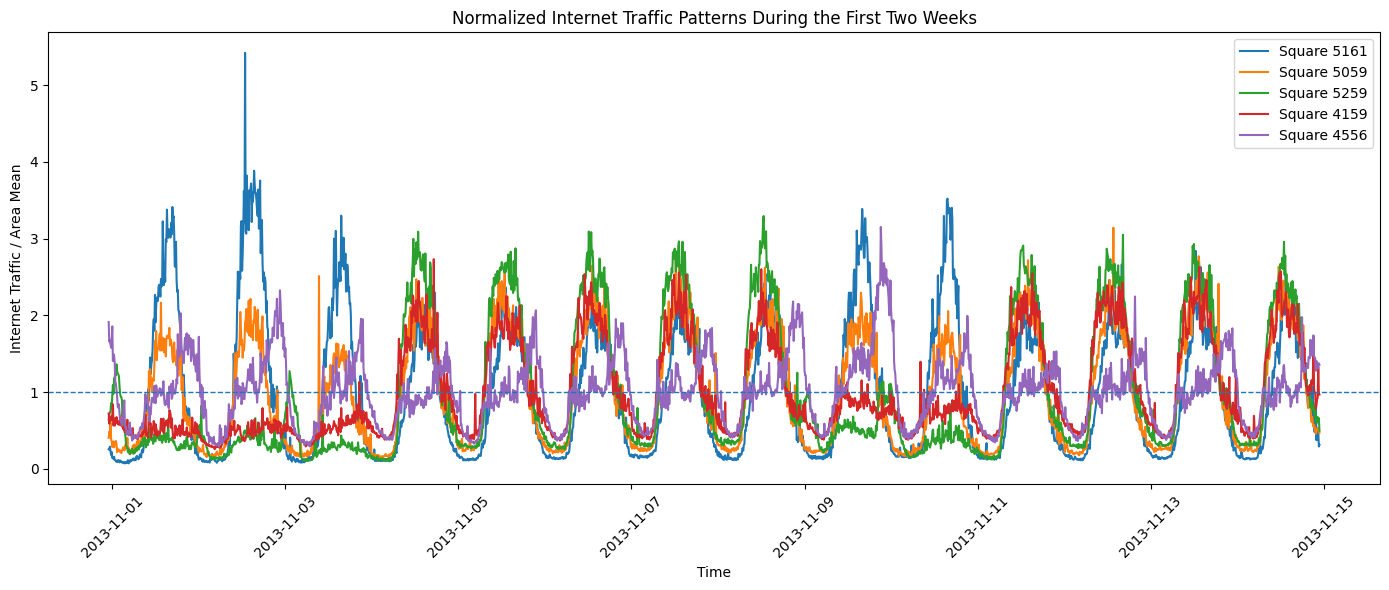

In [ ]:
# Normalized Temporal Comparison

comparison_data = first_two_weeks.copy()

square_means = (
    comparison_data
    .groupby("square_id")["internet"]
    .transform("mean")
)

comparison_data["internet_normalized"] = (comparison_data["internet"] / square_means)

plt.figure(figsize=(14, 6))

for square_id in selected_square_ids:

    square_data = comparison_data[comparison_data["square_id"] == square_id]

    plt.plot(square_data["datetime"],
        square_data["internet_normalized"],
        label=f"Square {square_id}"
    )

plt.axhline(1, linestyle="--", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Internet Traffic / Area Mean")
plt.title("Normalized Internet Traffic Patterns During the First Two Weeks")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

normalized_path = (FIGURES_DIR/ "internet_traffic_normalized_first_two_weeks.png")

plt.savefig(normalized_path, dpi=300, bbox_inches="tight")

plt.show()

The time-series plots show a strong recurring **daily pattern** across the five selected geographical areas. Traffic generally remains low during **nighttime and early-morning** periods, increases during the day, and reaches pronounced peaks before declining again. This pattern is repeated across much of the two-week period, indicating the presence of strong short-term temporal dependence and daily periodicity.

Despite these common patterns, the geographical areas exhibit different temporal characteristics. **Square 5161** shows particularly large fluctuations at the beginning of the observation period, including an unusually high normalized peak around November 2. **Square 5259** exhibits relatively consistent daily peaks, while **Square 4159** has a lower-amplitude pattern. **Square 4556** also shows distinct peaks at different periods of the day and several short-term fluctuations. These differences indicate that geographical areas share some common temporal structure but are not temporally identical.

The normalized comparison also shows that differences in traffic scale do not fully explain the observed variation. After normalization by each area's mean traffic, recurring patterns remain visible across several areas. This suggests that both common temporal patterns and area-specific dynamics may be relevant to forecasting. The presence of sharp, irregular spikes, particularly for Square 5161, also provides potential challenging periods for forecasting models.


## 2.5. Additional analyses using the highest-traffic area

### Analysis 1. Autocorrelation analysis

The square 5161 is highest traffic area. We'll load and calculate autocorrelation at meaningful lags.

- lag 1	   --> 10 minutes
- lag 6	   --> 1 hour
- lag 144	 --> 1 day
- etc. etc.

This gives us both short-term dependence and daily/weekly dependence.

In [ ]:
HIGHEST_TRAFFIC_SQUARE = 5161

square_5161 = pd.read_parquet(MASTER_PARQUET, columns=["square_id", "timestamp", "internet"])
square_5161 = (
    square_5161[
        square_5161["square_id"] == HIGHEST_TRAFFIC_SQUARE
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

square_5161["datetime"] = pd.to_datetime(square_5161["timestamp"], unit="ms")
traffic_5161 = square_5161["internet"]

print("=" * 70)
print("AUTOCORRELATION ANALYSIS — SQUARE 5161")
print("=" * 70)

print(f"Observations: {len(traffic_5161):,}")
print(f"Missing values: {traffic_5161.isna().sum():,}")
print(f"Time range: {square_5161['datetime'].min()} to {square_5161['datetime'].max()}")

lags = [1, 6, 12, 36, 72,
        144, 288, 432, 1008]

autocorrelation_results = []

for lag in lags:
    autocorrelation_results.append({
        "lag": lag,
        "time_difference": (pd.Timedelta(minutes=10 * lag)),
        "autocorrelation": (traffic_5161.autocorr(lag=lag))
    })

autocorrelation_df = pd.DataFrame(autocorrelation_results)
display(autocorrelation_df)

AUTOCORRELATION ANALYSIS — SQUARE 5161
Observations: 8,928
Missing values: 0
Time range: 2013-10-31 23:00:00 to 2014-01-01 22:50:00


,lag,time_difference,autocorrelation
0,1,0 days 00:10:00,0.987188
1,6,0 days 01:00:00,0.939273
2,12,0 days 02:00:00,0.819463
3,36,0 days 06:00:00,0.009908
4,72,0 days 12:00:00,-0.686318
5,144,1 days 00:00:00,0.893011
6,288,2 days 00:00:00,0.801885
7,432,3 days 00:00:00,0.784063
8,1008,7 days 00:00:00,0.929249


Let's now Visualize the autocorrelation at selected lags

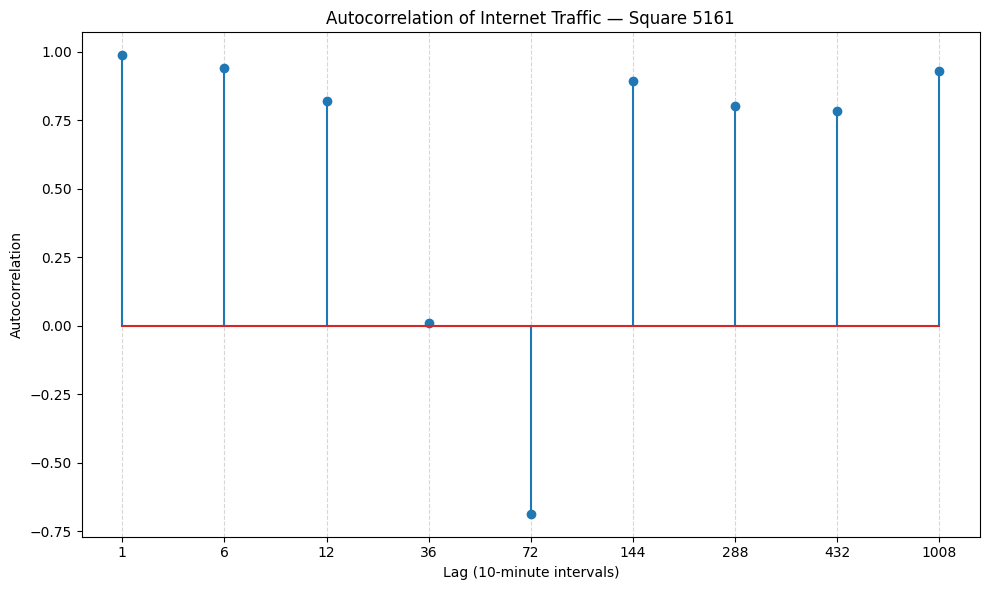

In [ ]:
plt.figure(figsize=(10, 6))

# 1. Use the DataFrame index (0, 1, 2...) for even spacing on the x-axis
plt.stem(autocorrelation_df.index, autocorrelation_df["autocorrelation"])

plt.xlabel("Lag (10-minute intervals)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Internet Traffic — Square 5161")

# 2. Map the index positions to your actual custom lag labels
plt.xticks(
    ticks=autocorrelation_df.index,
    labels=autocorrelation_df["lag"],
)

# Optional: Add a grid to make the evenly spaced vertical lines clearer
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

acf_path = (FIGURES_DIR / "square_5161_autocorrelation.png")
plt.savefig(acf_path, dpi=300, bbox_inches="tight")

plt.show()

To further characterize the forecasting problem, autocorrelation and periodicity analyses were conducted for Square 5161, the geographical area with the highest total Internet traffic. The autocorrelation results show **strong short-term temporal dependence**, with correlations of 0.987 at a 10-minute lag, 0.939 at one hour, and 0.819 at two hours. The autocorrelation decreases to approximately zero at six hours and becomes strongly negative at 12 hours (−0.686). This negative relationship is consistent with the strong difference between daytime and nighttime traffic observed in the daily profile.

### Analysis 2. Daily and Weekly Periodicity

For this, we will analysis:

- **Daily periodicity** (144  10-minute observations in a day): We'll calculate the average traffic for each 10-minute position within a day.

- **Weekly periodicity** (1008 observations in a week): We'll calculate average traffic for each day of the week.

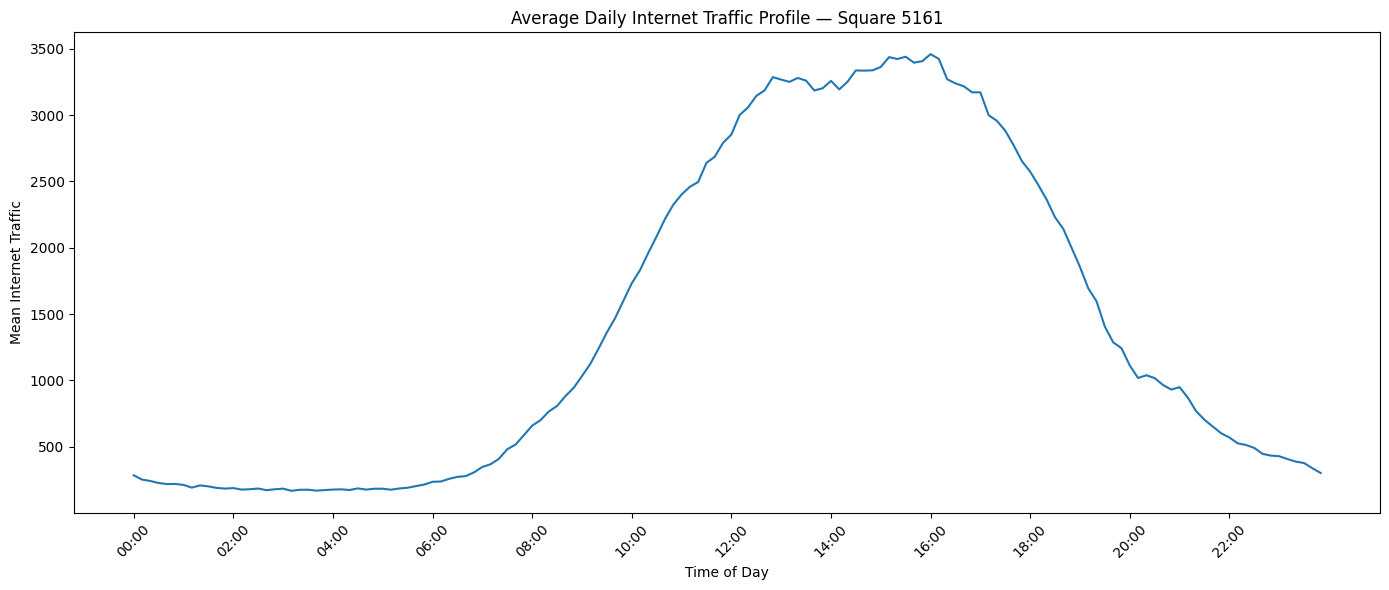

In [ ]:
# Daily Periodicity

square_5161["time_of_day"] = (square_5161["datetime"].dt.hour * 60
                              + square_5161["datetime"].dt.minute)

daily_profile = (square_5161.groupby("time_of_day")["internet"]
                 .mean().reset_index())
daily_profile["hour"] = (daily_profile["time_of_day"] // 60)
daily_profile["minute"] = (daily_profile["time_of_day"] % 60)

daily_profile["time_label"] = (
    daily_profile["hour"].astype(str).str.zfill(2)
    + ":"
    + daily_profile["minute"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 6))
plt.plot(daily_profile["time_label"], daily_profile["internet"])

plt.xlabel("Time of Day")
plt.ylabel("Mean Internet Traffic")
plt.title("Average Daily Internet Traffic Profile — Square 5161")

# Show fewer x-axis labels for readability
plt.xticks(
    range(0, len(daily_profile), 12),
    daily_profile["time_label"].iloc[::12],
    rotation=45
)

plt.tight_layout()

daily_profile_path = (FIGURES_DIR / "square_5161_daily_periodicity.png")

plt.savefig(daily_profile_path, dpi=300, bbox_inches="tight")

plt.show()

From the plot above, we notice that average traffic is very low during approximately **00:00–05:00**, then gradually increases from the morning. It rises strongly through the morning and reaches a broad high-traffic period from approximately **13:00 to 17:00**, with the highest average level around **15:00–16:00**. After approximately **17:00**, traffic declines progressively through the evening and returns to relatively low levels late at night.

So the daily profile is not just a random collection of peaks. It forms a very **clear and smooth daily cycle**.

AVERAGE INTERNET TRAFFIC BY DAY OF WEEK — SQUARE 5161


,day_of_week,internet
0,Monday,1303.161133
1,Tuesday,1254.384766
2,Wednesday,1160.011353
3,Thursday,1267.988281
4,Friday,1431.885376
5,Saturday,1855.161499
6,Sunday,1698.088867


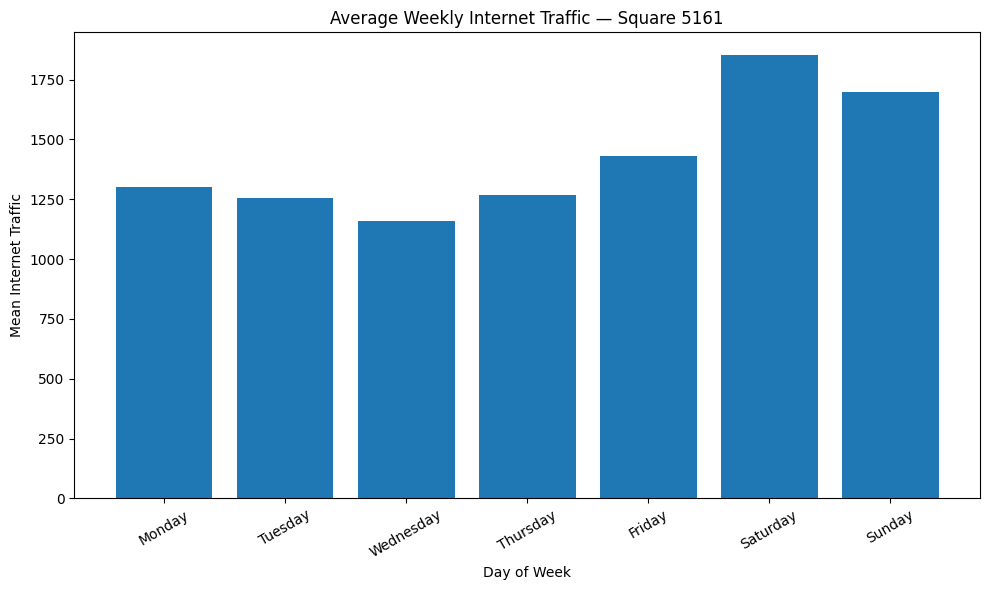

In [ ]:
# Weekly Periodicity

square_5161["day_of_week"] = (square_5161["datetime"].dt.day_name())

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly_profile = (square_5161.groupby("day_of_week")["internet"]
                  .mean().reindex(day_order).reset_index())

print("=" * 70)
print("AVERAGE INTERNET TRAFFIC BY DAY OF WEEK — SQUARE 5161")
print("=" * 70)

display(weekly_profile)

plt.figure(figsize=(10, 6))
plt.bar(weekly_profile["day_of_week"], weekly_profile["internet"])

plt.xlabel("Day of Week")
plt.ylabel("Mean Internet Traffic")
plt.title("Average Weekly Internet Traffic — Square 5161")

plt.xticks(rotation=30)
plt.tight_layout()

weekly_profile_path = (FIGURES_DIR / "square_5161_weekly_periodicity.png")

plt.savefig(weekly_profile_path, dpi=300, bbox_inches="tight")

plt.show()

Weekly temporal structure is also evident. The autocorrelation at lag 1008, corresponding to seven days, is 0.929, indicating a strong relationship between observations separated by one week. The average traffic by day of week further shows systematic variation, with the highest mean traffic occurring on Saturday (1,855.16), followed by Sunday (1,698.09), while Wednesday has the lowest mean (1,160.01). However, these weekday differences should be interpreted as **descriptive evidence** because **the autocorrelation at the weekly** lag provides stronger evidence of recurring weekly structure.